In [1]:
from triang_mesh          import TriMesh, refine_mesh_1to4
from patches       import PatchCoverage
from rbf           import RBF
from interpolator  import PUMInterpolator
from perlin_noise import PerlinNoise
import triangle
from potential import NoisePotential2D
from utils import plot_noise_mesh, plot_mesh, plot_layers_mesh, refine_around_brder
import numpy as np
from visualization import plot_patches, plot_patches_v2, plot_combined_field
import matplotlib.pyplot as plt

In [2]:
def u_exact(x, y):
    return np.sin(np.pi * x) * np.sin(np.pi * y)

def du_dx_exact(x, y):
    return np.pi * np.cos(np.pi * x) * np.sin(np.pi * y)

def du_dy_exact(x, y):
    return np.pi * np.sin(np.pi * x) * np.cos(np.pi * y)

In [3]:
def process_mesh_interpolation(mesh_name, factor=1.0, H=0.5):
    mesh_file = triangle.load("..\\meshes\\triangle_files", mesh_name)
    coarse_mesh = triangle.triangulate(mesh_file, "pq5a150")

    print(coarse_mesh["vertices"].min(), coarse_mesh["vertices"].max())
    mins = coarse_mesh["vertices"].min(axis=0)
    maxs = coarse_mesh["vertices"].max(axis=0)

    # Normalizing mesh vertices range
    coarse_mesh["vertices"] = 2 * (coarse_mesh["vertices"] - mins) / (maxs - mins) - 1
    print(coarse_mesh["vertices"].min(), coarse_mesh["vertices"].max())

    mesh_obj = TriMesh(coarse_mesh)

    coarse_mesh_field = u_exact(coarse_mesh["vertices"][:,0], coarse_mesh["vertices"][:,1])

    print(H)
    coverage = PatchCoverage(mesh_obj, H=H, delta=0.2, min_nodes_per_patch=4)
    coverage.summary() # Resumo da cobertura

    radius = np.mean(coverage.radius_list)

    epsilon = 1 / (factor*radius)

    print(radius)
    print(factor, epsilon)

    #coverage.patches -> acessar radius (lista)
    # printar e verificar se são os mesmos 
    # Se não for, calcular media - passar para o epsilon o inverso da media do raio
    # epsilon fica amarrado ao raio

    interp = NoisePotential2D(mesh_obj, coverage, RBF(epsilon=epsilon))
    interp.fit(coarse_mesh_field)

    pts, tri  = refine_mesh_1to4(coarse_mesh["vertices"], coarse_mesh["triangles"])
    fine_mesh = {}
    fine_mesh["vertices"] = pts
    fine_mesh["triangles"] = tri
    fine_mesh_obj = TriMesh(fine_mesh)

    fine_scalar_field = interp.evaluate(fine_mesh["vertices"])

    # Computing the interpolation error

    exact_fine_scalar_field  = u_exact(fine_mesh["vertices"][:, 0], fine_mesh["vertices"][:, 1])
    err   = np.abs(exact_fine_scalar_field - fine_scalar_field)
    l_inf = float(err.max())
    l1 = np.sum(err)
    l2 = float(np.sqrt(np.mean(err**2)))
    
    print('L inf:', l_inf, 'L1:', l1, 'L2:', l2)

    return l1, l2, l_inf, radius, epsilon


In [4]:
meshes = ["fishdp", "alienbs", "cartdp", "deer20dp", "dog", \
		   "dovedp", "duckdp", "knightdp", "dogbs", "crowndp"]

fact_list = [0.1, 0.5, 1.0, 1.5, 2.0, 4.0, 6.0, 8.0]

l1_list = []
l2_list = []
linf_list = []
radius_list = []
epsilon_list = []

for fact in fact_list:
	mean_linf = []
	mean_l1 = []
	mean_l2 = []
	radius_meshes = []
	epsilon_meshes = []
	for mesh in meshes:
		l1, l2, linf, radius, epsilon = process_mesh_interpolation(mesh, factor = fact)
		mean_l1.append(l1)
		mean_l2.append(l2)
		mean_linf.append(linf)
		radius_meshes.append(radius)
		epsilon_meshes.append(epsilon)
	
	l1_list.append(np.mean(np.asarray(mean_l1)))
	l2_list.append(np.mean(np.asarray(mean_l2)))
	linf_list.append(np.mean(np.asarray(mean_linf)))
	radius_list.append(radius_meshes)
	epsilon_list.append(epsilon_meshes)


-100.0 141.5
-1.0 1.0
0.5
70
5
218
156
93
181
264
182
115
104
48
34

Resumo da cobertura:
  n_patches           : 9
  H                   : 0.5
  delta               : 0.2
  min_nodes           : 70
  max_nodes           : 264
  mean_nodes          : 162.88888888888889
  min_coverage        : 1
  max_coverage        : 4
  mean_coverage       : 1.87708066581306
  full_coverage       : True
0.4242640687119285
0.1 23.57022603955158
L inf: 0.42048054163276355 L1: 0.5298543464668769 L2: 0.007704791810248852
-1001.81 828.5
-1.0 1.0
0.5
407
672
708
477
514
825
858
564
455
769
757
422
379
395
432
327

Resumo da cobertura:
  n_patches           : 16
  H                   : 0.5
  delta               : 0.2
  min_nodes           : 327
  max_nodes           : 858
  mean_nodes          : 560.0625
  min_coverage        : 1
  max_coverage        : 4
  mean_coverage       : 2.1546044722289013
  full_coverage       : True
0.4242640687119285
0.1 23.57022603955158
L inf: 0.00021577826118666932 L1: 0.03362

KeyboardInterrupt: 

In [ ]:
print(l1_list)
print(l2_list)
print(linf_list)
print(radius_list)
print(epsilon_list)

[0.10539316072853266, 0.10716067387331411, 0.1097295419618584, 0.11328082876911554, 0.12562815991910833, 0.3323502368752709, 0.8359995124294286, 1.692821823520187]
[0.0008115632074148608, 0.0008121821355684143, 0.0008136363809648766, 0.000816056594563037, 0.0008228522617050697, 0.0009218200066178023, 0.0011731990118309225, 0.0016152447459875166]
[0.04287949561011065, 0.04289149369100166, 0.04288821554328113, 0.04289657377500135, 0.04294575691727685, 0.044476071238317774, 0.047898881512906846, 0.052964687205936514]
[[0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285], [0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.4242640687119285], [0.4242640687119285, 0.4242640687119285, 0.4242640687119285, 0.424264068711

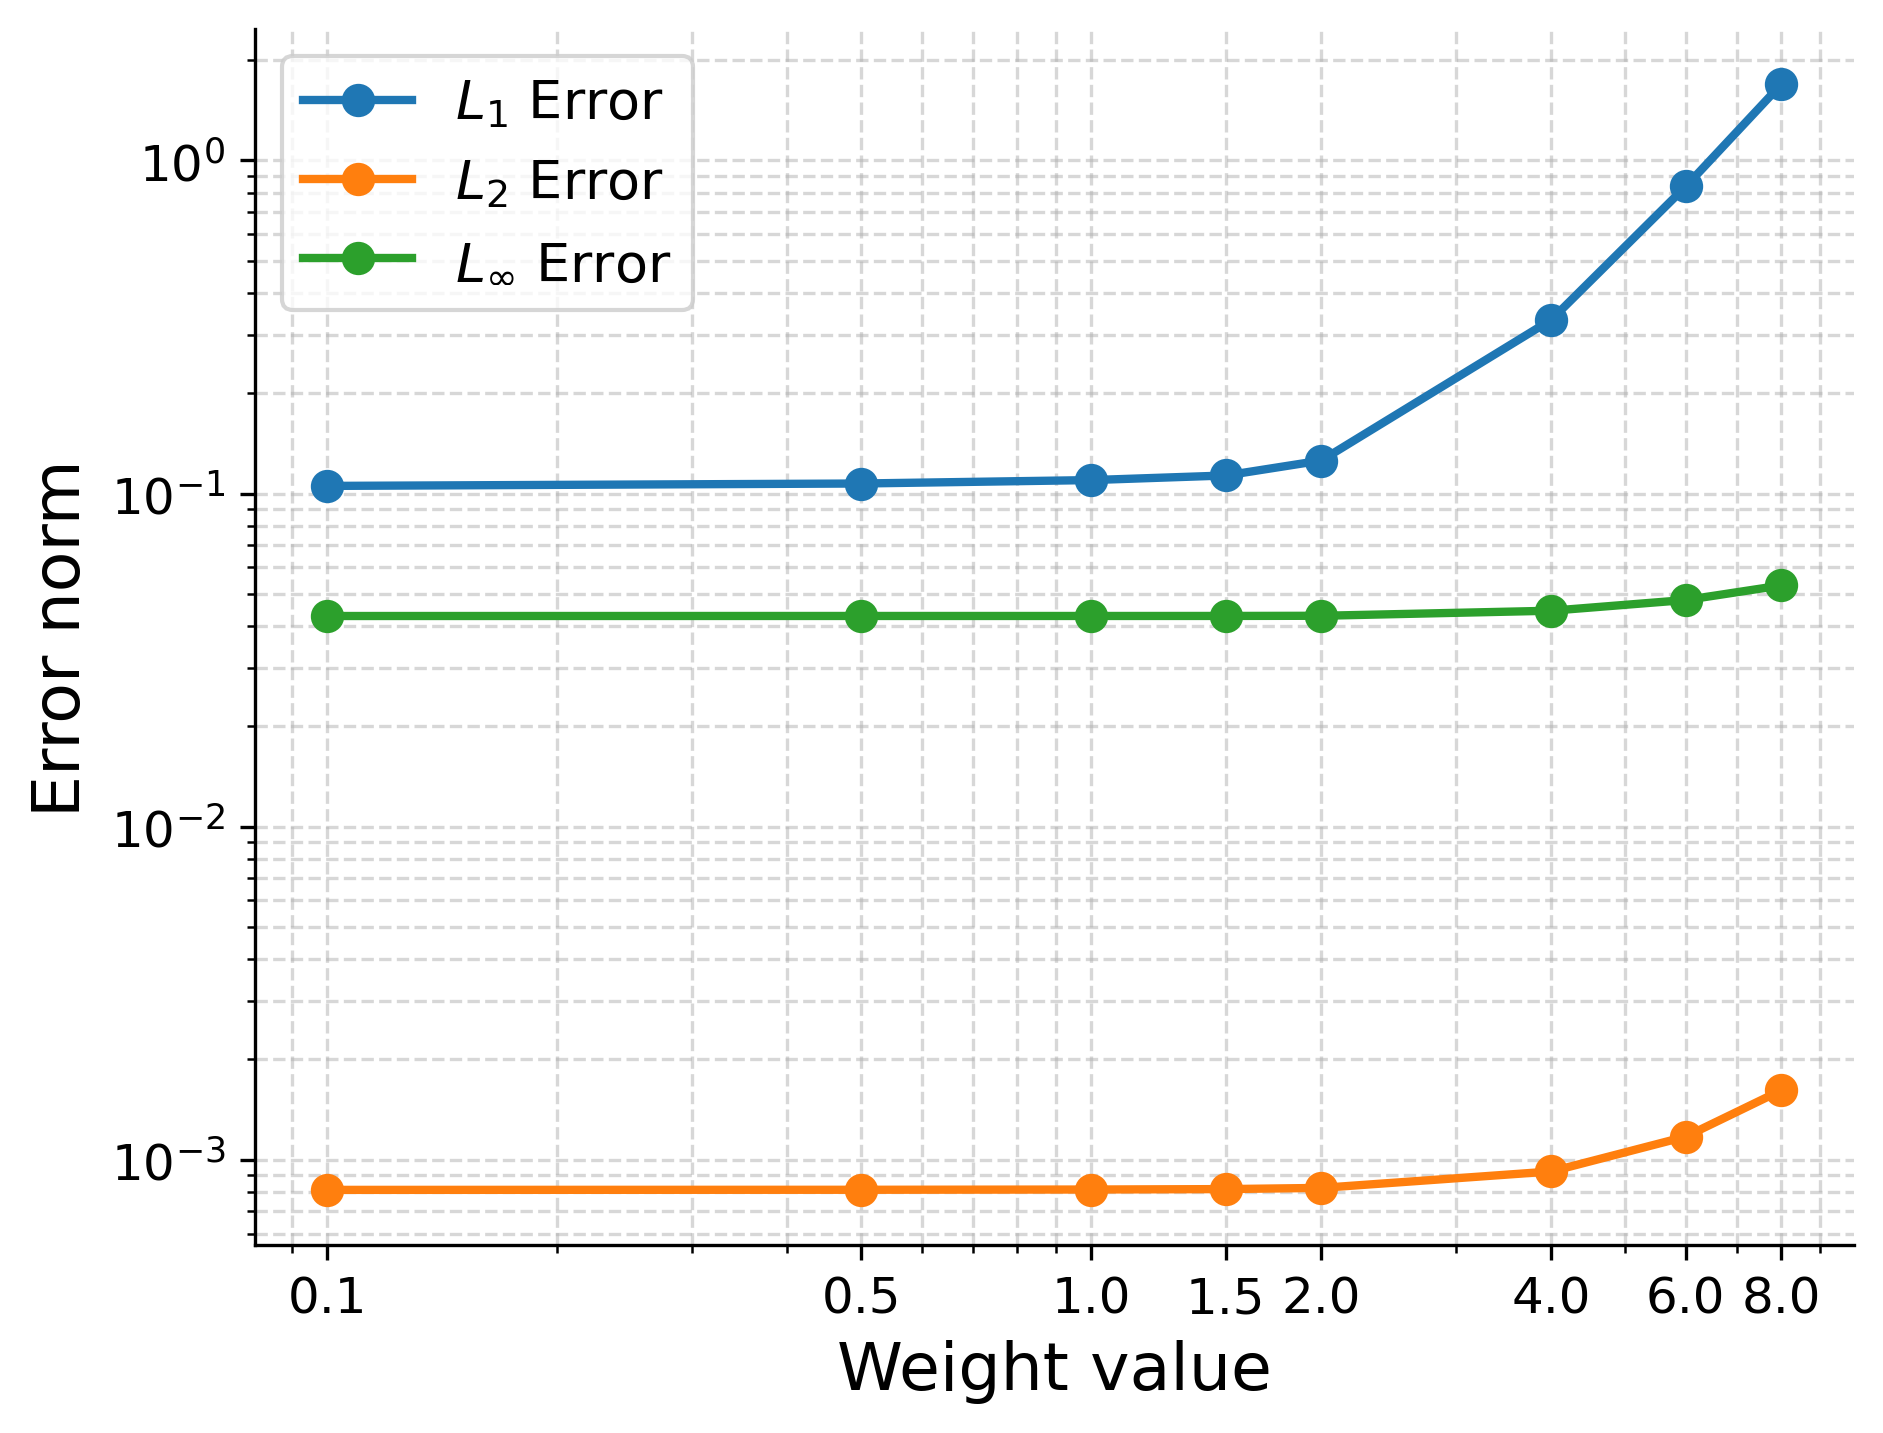

In [ ]:
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "legend.fontsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.linewidth": 2.0,
    "lines.markersize": 7,
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "text.usetex": False,   # True if LaTeX installed
})

fig, ax = plt.subplots(figsize=(6.5, 5))

ax.loglog(
    fact_list,
    l1_list,
    marker='o',
    label=r'$L_1$ Error'
)

ax.loglog(
    fact_list,
    l2_list,
    marker='o',
    label=r'$L_2$ Error'
)

ax.loglog(
    fact_list,
    linf_list,
    marker='o',
    label=r'$L_\infty$ Error'
)

#ax.set_xlabel(r'RBF parameter $\epsilon$')
ax.set_xlabel(r'Weight value')
ax.set_ylabel(r'Error norm')

ax.set_xticks(fact_list)
ax.set_xticklabels([str(v) for v in fact_list])

#ax.invert_xaxis()

ax.grid(
    True,
    which='both',
    linestyle='--',
    alpha=0.5
)

ax.legend(frameon=True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig("rbf_error_plot.pdf")
plt.savefig("rbf_error_plot.png")

plt.show()

In [ ]:
# varying radius size instead of factor

meshes = ["fishdp", "alienbs", "cartdp", "deer20dp", "dog", \
		   "dovedp", "duckdp", "knightdp", "dogbs", "crowndp"]

rad_list = [0.1, 0.2, 0.3, 0.4, 0.5, 0.8, 1.0, 1.5, 2.0]

l1_list = []
l2_list = []
linf_list = []


for rad in rad_list:
	mean_linf = []
	mean_l1 = []
	mean_l2 = []
	for mesh in meshes:
		l1, l2, linf = process_mesh_interpolation(mesh, H = rad)
		mean_l1.append(l1)
		mean_l2.append(l2)
		mean_linf.append(linf)
	
	l1_list.append(np.mean(np.asarray(mean_l1)))
	l2_list.append(np.mean(np.asarray(mean_l2)))
	linf_list.append(np.mean(np.asarray(mean_linf)))

print(l1_list)
print(l2_list)
print(linf_list)

-100.0 141.5
-1.0 1.0
0.1

Resumo da cobertura:
  n_patches           : 177
  H                   : 0.1
  delta               : 0.2
  min_nodes           : 4
  max_nodes           : 14
  mean_nodes          : 9.36723163841808
  min_coverage        : 1
  max_coverage        : 4
  mean_coverage       : 2.12291933418694
  full_coverage       : True
0.08485281374238574
1.0 11.785113019775787
L inf: 0.13758942789294848 L1: 1.677768646933779 L2: 0.002751827780807207


ValueError: too many values to unpack (expected 3)

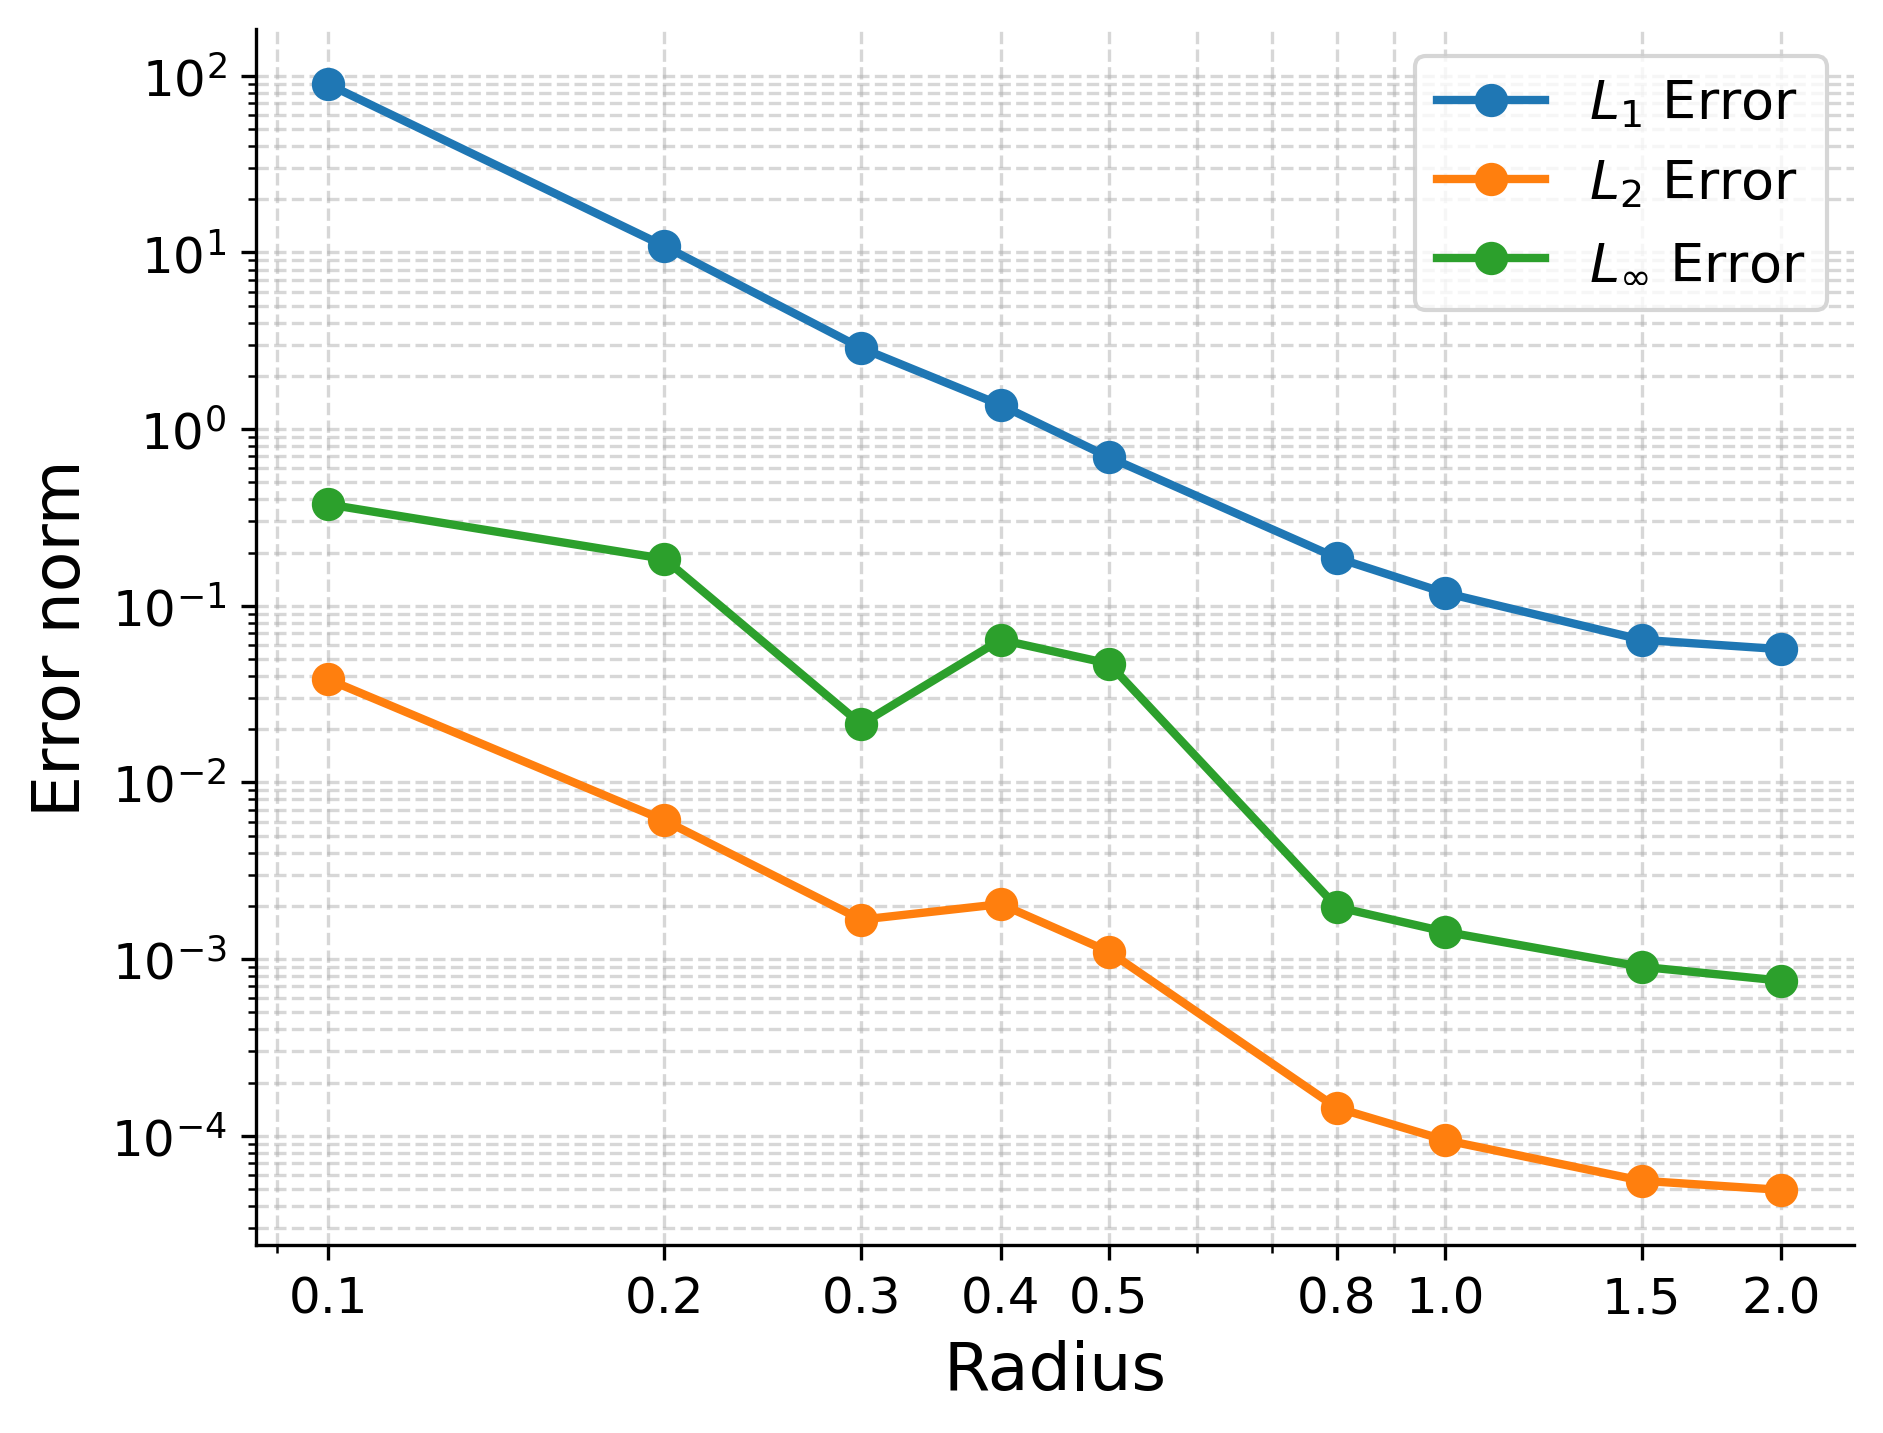

In [ ]:
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "legend.fontsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.linewidth": 2.0,
    "lines.markersize": 7,
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "text.usetex": False,   # True if LaTeX installed
})

fig, ax = plt.subplots(figsize=(6.5, 5))

ax.loglog(
    rad_list,
    l1_list,
    marker='o',
    label=r'$L_1$ Error'
)

ax.loglog(
    rad_list,
    l2_list,
    marker='o',#'s',
    label=r'$L_2$ Error'
)

ax.loglog(
    rad_list,
    linf_list,
    marker='o',#'^',
    label=r'$L_\infty$ Error'
)

ax.set_xlabel(r'Radius')
ax.set_ylabel(r'Error norm')

ax.set_xticks(rad_list)
ax.set_xticklabels([str(v) for v in rad_list])

#ax.invert_xaxis()

ax.grid(
    True,
    which='both',
    linestyle='--',
    alpha=0.5
)

ax.legend(frameon=True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig("radius_error_plot.pdf")
plt.savefig("radius_error_plot.png")

plt.show()

## Saving interpolation mesh

-375.08 359.5
-1.0 1.0
144
187
158
122
168
182
35
102
181
73
183
109

Resumo da cobertura:
  n_patches           : 11
  H                   : 0.5
  delta               : 0.2
  min_nodes           : 73
  max_nodes           : 223
  mean_nodes          : 159.8181818181818
  min_coverage        : 1
  max_coverage        : 4
  mean_coverage       : 1.9775028121484814
  full_coverage       : True
0.001946624237905259 0.19147031855096727 0.00017665621342270632


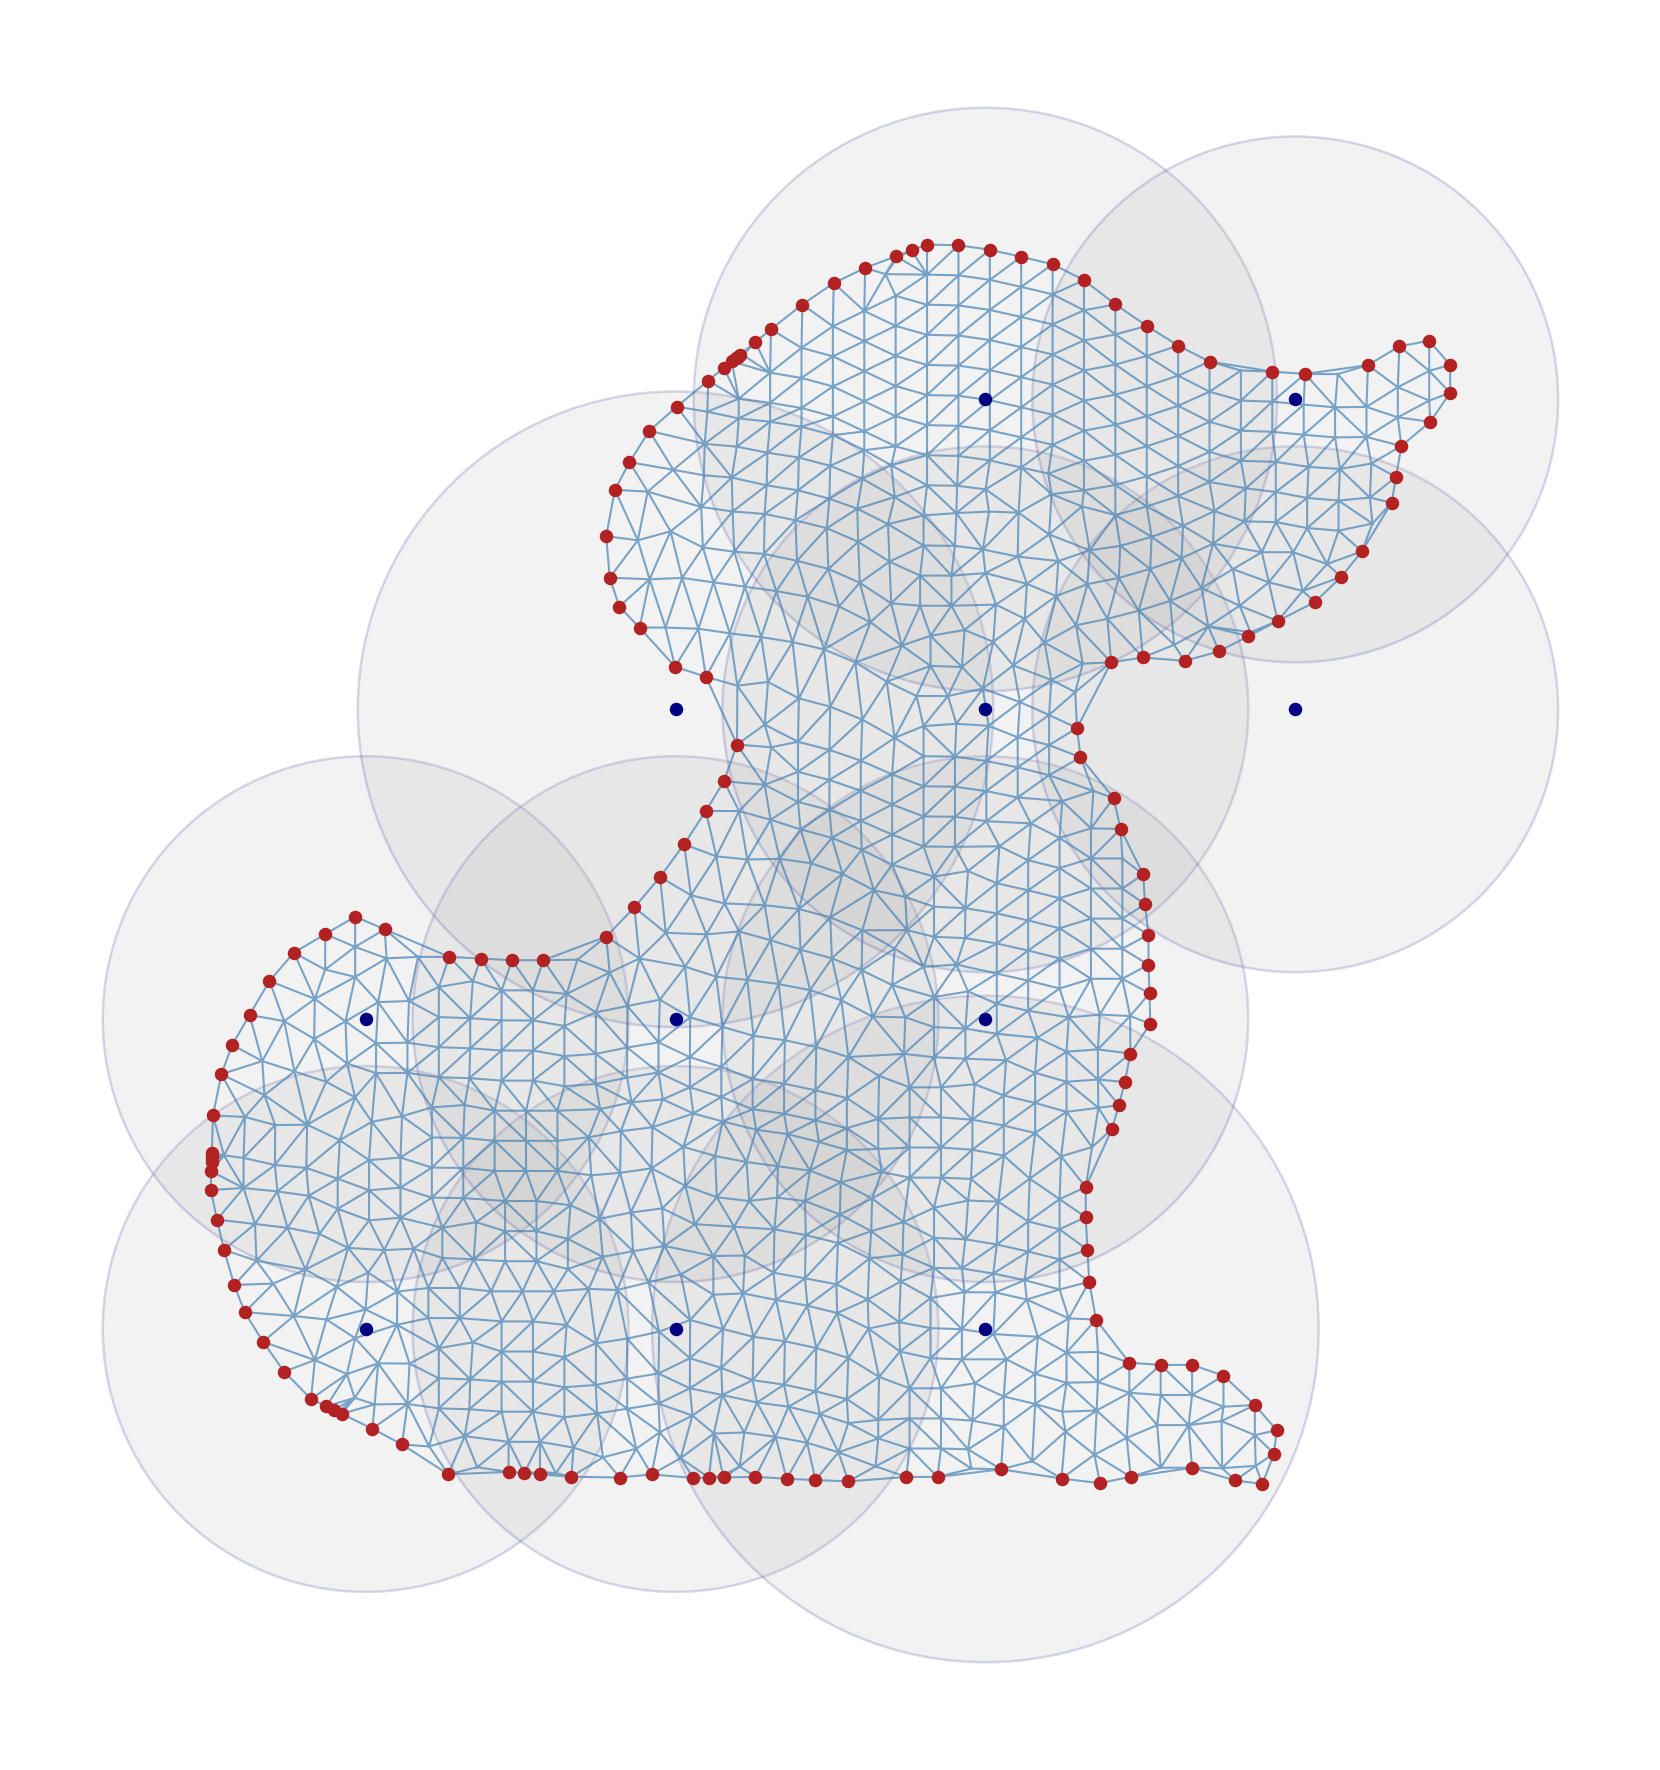

In [7]:
mesh_file = triangle.load("..\\meshes\\triangle_files", "dog")
coarse_mesh = triangle.triangulate(mesh_file, "pq5a150")

print(coarse_mesh["vertices"].min(), coarse_mesh["vertices"].max())
mins = coarse_mesh["vertices"].min(axis=0)
maxs = coarse_mesh["vertices"].max(axis=0)

# Normalizing mesh vertices range
coarse_mesh["vertices"] = 2 * (coarse_mesh["vertices"] - mins) / (maxs - mins) - 1
print(coarse_mesh["vertices"].min(), coarse_mesh["vertices"].max())

mesh_obj = TriMesh(coarse_mesh)

coarse_mesh_field = u_exact(coarse_mesh["vertices"][:,0], coarse_mesh["vertices"][:,1])

coverage = PatchCoverage(mesh_obj, H=0.5, delta=0.2, min_nodes_per_patch=4)
coverage.summary() # Resumo da cobertura

#radius = np.mean(coverage.radius_list)
#epsilon = 1 / (4.0*radius)

interp = NoisePotential2D(mesh_obj, coverage, RBF(epsilon=1.0))
interp.fit(coarse_mesh_field)

mesh_obj.save_mesh_paraview(coarse_mesh, phi=coarse_mesh_field, out_name="dog_coarse.vtu")

pts, tri  = refine_mesh_1to4(coarse_mesh["vertices"], coarse_mesh["triangles"])
fine_mesh = {}
fine_mesh["vertices"] = pts
fine_mesh["triangles"] = tri
fine_mesh_obj = TriMesh(fine_mesh)

fine_scalar_field = interp.evaluate(fine_mesh["vertices"])

exact_field = u_exact(fine_mesh["vertices"][:,0], fine_mesh["vertices"][:,1])
diff_field = exact_field - fine_scalar_field

err   = np.abs(exact_field - fine_scalar_field)
l_inf = float(err.max())
l1 = np.sum(err)
l2 = float(np.sqrt(np.mean(err**2)))

print(l_inf, l1, l2)

fine_mesh_obj.save_mesh_paraview(fine_mesh, phi=fine_scalar_field, out_name="dog_fine_interp.vtu")
fine_mesh_obj.save_mesh_paraview(fine_mesh, phi=exact_field, out_name="dog_fine_exact.vtu")
fine_mesh_obj.save_mesh_paraview(fine_mesh, phi=diff_field, out_name="dog_fine_diff.vtu")

ax = plot_patches_v2(mesh_obj, coverage, alpha=0.15)
plt.savefig("patches.pdf",bbox_inches="tight", pad_inches=0)
plt.savefig("patches.png",bbox_inches="tight", pad_inches=0)
